
# Fitting NuSTAR Spectra: Simultaneous Fitting

A real example from [Cooper2021]_ of fitting two NuSTAR spectra simultaneously.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.exceptions import VisibleDeprecationWarning
from parfive import Downloader

from sunkit_spex.legacy.fitting.fitter import Fitter

warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
except AttributeError:
    warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

Set up some plotting numbers



In [2]:
spec_single_plot_size = (8, 10)
spec_plot_size = (25, 10)
spec_font_size = 18
default_font_size = 10
x_limits, y_limits = [1.6, 8.5], [1e-1, 1e3]

Download the example data



In [3]:
# dl = Downloader()

# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/nustar/m10_1616_1620/"
# file_names = [
#     "nu80415202001A06_chu13_N_cl_grade0_sr.pha",
#     "nu80415202001A06_chu13_N_cl_grade0_sr.arf",
#     "nu80415202001A06_chu13_N_cl_grade0_sr.rmf",
#     "nu80415202001B06_chu13_N_cl_grade0_sr.pha",
#     "nu80415202001B06_chu13_N_cl_grade0_sr.arf",
#     "nu80415202001B06_chu13_N_cl_grade0_sr.rmf",
# ]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

Files Downloaded:   0%|          | 0/6 [00:00<?, ?file/s]

nu80415202001A06_chu13_N_cl_grade0_sr.arf:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

nu80415202001B06_chu13_N_cl_grade0_sr.arf:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

nu80415202001A06_chu13_N_cl_grade0_sr.rmf:   0%|          | 0.00/35.3M [00:00<?, ?B/s]

nu80415202001B06_chu13_N_cl_grade0_sr.pha:   0%|          | 0.00/132k [00:00<?, ?B/s]

nu80415202001A06_chu13_N_cl_grade0_sr.pha:   0%|          | 0.00/132k [00:00<?, ?B/s]

nu80415202001B06_chu13_N_cl_grade0_sr.rmf:   0%|          | 0.00/34.3M [00:00<?, ?B/s]

Load in your data files, here we load in 2 spectra



In [4]:
_dir = "data/"
spec = Fitter(
    pha_file=[_dir + "nu80415202001A06_chu13_N_cl_grade0_sr.pha", _dir + "nu80415202001B06_chu13_N_cl_grade0_sr.pha"]
)

Next you can define a model, here we go for a 2 component isothermal model
C parameter accounts for systematic offset between two different telescopes



In [5]:
spec.model = "C*(f_vth + f_vth)"

Set your count energy fitting range. Here we choose 2.5--8.1 keV



In [6]:
spec.energy_fitting_range = [2.5, 8.1]

Freeze parameters
`spec.params["C_spectrum1"] = "frozen"` is equivalent



In [7]:
spec.params["C_spectrum1"] = {"Status": "frozen"}

To set the initial value and boundary of your parameters we can do the following.



In [8]:
spec.params["T1_spectrum1"] = {"Value": 3.05, "Bounds": (2.5, 6)}
spec.params["EM1_spectrum1"] = {"Value": 1.7, "Bounds": (0.5, 3.5)}
spec.params["T2_spectrum1"] = {"Value": 6.6, "Bounds": (4, 10)}
spec.params["EM2_spectrum1"] = {"Value": 0.004, "Bounds": (1e-4, 2e-1)}

Free the constant (was tied to `"C_spectrum1"`) to account for systematic offset between NuSTAR FPMs



In [9]:
spec.params["C_spectrum2"] = {"Status": "free", "Bounds": (0.5, 2)}

print(spec.params)

                          Status  Value         Bounds       Error
T1_spectrum1                free  3.050       (2.5, 6)  (0.0, 0.0)
EM1_spectrum1               free  1.700     (0.5, 3.5)  (0.0, 0.0)
T2_spectrum1                free  6.600        (4, 10)  (0.0, 0.0)
EM2_spectrum1               free  0.004  (0.0001, 0.2)  (0.0, 0.0)
C_spectrum1               frozen  1.000    (0.0, None)  (0.0, 0.0)
T1_spectrum2    tie_T1_spectrum1  1.000    (0.0, None)  (0.0, 0.0)
EM1_spectrum2  tie_EM1_spectrum1  1.000    (0.0, None)  (0.0, 0.0)
T2_spectrum2    tie_T2_spectrum1  1.000    (0.0, None)  (0.0, 0.0)
EM2_spectrum2  tie_EM2_spectrum1  1.000    (0.0, None)  (0.0, 0.0)
C_spectrum2                 free  1.000       (0.5, 2)  (0.0, 0.0)


We can also display the parameter table as an astropy table



In [10]:
print(spec.show_params)

    Param           Status      ...     Bounds             Error          
                                ...   (min, max)           (-, +)         
------------- ----------------- ... ------------- ------------------------
 T1_spectrum1              free ...      (2.5, 6) (  0.00e+00,   0.00e+00)
EM1_spectrum1              free ...    (0.5, 3.5) (  0.00e+00,   0.00e+00)
 T2_spectrum1              free ...       (4, 10) (  0.00e+00,   0.00e+00)
EM2_spectrum1              free ... (0.0001, 0.2) (  0.00e+00,   0.00e+00)
  C_spectrum1            frozen ...   (0.0, None) (  0.00e+00,   0.00e+00)
 T1_spectrum2  tie_T1_spectrum1 ...   (0.0, None) (  0.00e+00,   0.00e+00)
EM1_spectrum2 tie_EM1_spectrum1 ...   (0.0, None) (  0.00e+00,   0.00e+00)
 T2_spectrum2  tie_T2_spectrum1 ...   (0.0, None) (  0.00e+00,   0.00e+00)
EM2_spectrum2 tie_EM2_spectrum1 ...   (0.0, None) (  0.00e+00,   0.00e+00)
  C_spectrum2              free ...      (0.5, 2) (  0.00e+00,   0.00e+00)
    Fit Stat.       cstat

Fit and plot



2026-07-16T23:04:56Z INFO sunkit_spex.legacy.fitting.fitter 2814: Apply binning for plotting.


In spectrum1, 1  counts are left over from binning (bin min. 5) and will not be included when fitting or shown when plotted.


2026-07-16T23:04:56Z INFO sunkit_spex.legacy.fitting.fitter 2814: Apply binning for plotting.


In spectrum2, 1  counts are left over from binning (bin min. 5) and will not be included when fitting or shown when plotted.
In combined, 1.5  counts are left over from binning (bin min. 5) and will not be included when fitting or shown when plotted.


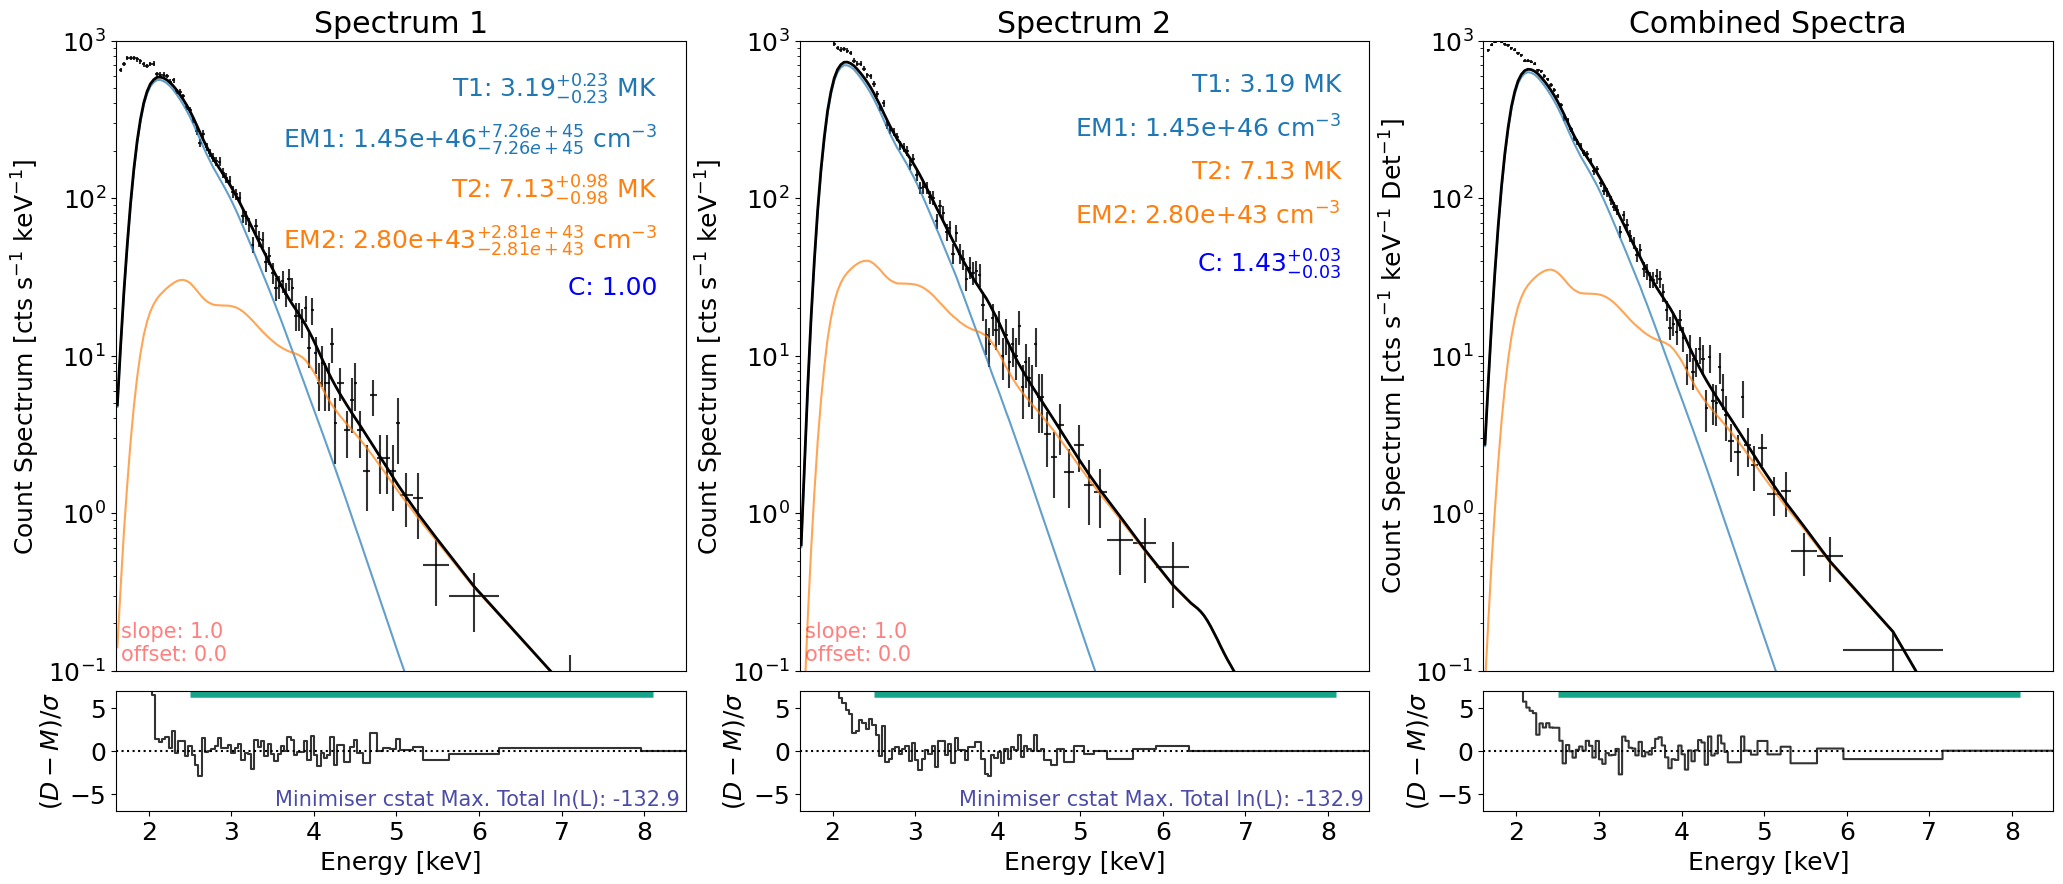

In [11]:
minimised_params = spec.fit(tol=1e-8)

plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
axes, res_axes = spec.plot(rebin=5)
for a in axes:
    a.set_xlim(x_limits)
    a.set_ylim(y_limits)
plt.show()
plt.rcParams["font.size"] = default_font_size

Comparison

+------------------------------------------+-----------------------------------------------+------------------------------------------+
| Model Parameter                          | XSPEC (Cooper et al. 2021) [*]_               | This Work                                |
+==========================================+===============================================+==========================================+
| Temperature 1 [MK]                       | $3.05^{+0.04}_{-0.35}$                  | 3.19\ |pm|\ 0.23                         |
+------------------------------------------+-----------------------------------------------+------------------------------------------+
| Emission Measure 1 [cm\ :sup:`-3`]       | $1.70^{+1.99}_{-0.08}\times10^{47}$     | 1.45 |pm| 0.72\ |x|\ 10 :sup:`46`        |
+------------------------------------------+-----------------------------------------------+------------------------------------------+
| Temperature 2 [MK]                       | $6.60^{+0.20}_{-0.61}$                  | 7.13\ |pm|\ 0.97                         |
+------------------------------------------+-----------------------------------------------+------------------------------------------+
| Emission Measure 2 [cm\ :sup:`-3`]       | $3.8^{+4.0}_{-0.7}\times10^{43}$        | 2.80 |pm| 2.80\ |x|\ 10 :sup:`43`        |
+------------------------------------------+-----------------------------------------------+------------------------------------------+

.. |pm| replace:: $\pm$
.. |x| replace:: $\times$
.. [*] Cooper *et al.* 2021's microflare 10, pre-flare.
.. [Cooper2021] https://academic.oup.com/mnras/article/507/3/3936/6354806



Although these values are slightly different (almost or are within error margins), it is important to note that XSPEC and sunkit-spex work from different atomic databases. We also note that for a similar isothermal fit the temperature can drop/rise if the emission measure rises/drops and so fitting not just one but two of these models allows for these to vary more. We do see that this work (for this microflare time) produces slightly higher temperatures but correspondingly lower emission measures.

The errors in this code also work under a Gaussian and independent assumption and so are likely underestimating the true error on each parameter.

**A Note On Parameter Handling**

Setting `spec.params["param_spec"] = string` will set the Status, `spec.params["param_spec"] = int` or `float` will set the Value, `spec.params["param_spec"] = tuple` will set the Bounds. E.g.,

```
   spec.params["T1_spectrum1"] = {"Value":3.05, "Bounds":(2.5, 6)}
```
is the same as doing

```
   spec.params["T1_spectrum1"] = 3.05
   spec.params["T1_spectrum1"] = (2.5, 6)
```
or

```
   spec.params["T1_spectrum1"] = [3.05, (2.5, 6)]
```


To tie one parameter to another we can either set that parameter to the one we want to tie it to or use `["tie", "tied", "bind", "tether", "join", "joined", "in_a_relationship_with"]`. E.g.,

```
   spec.params["EM1_spectrum2"] = spec.params["EM1_spectrum1"]
   spec.params["EM1_spectrum2"] = "JoIn_EM1_spectrum1"
   spec.params["EM1_spectrum2"] = {"Status":"bind_EM1_spectrum1"}
```

To stop a parameter from varying we can set its Status to `["frozen", "freeze", "chill", "fix", "fixed", "secure", "stick", "glue", "preserve", "cannot_move", "cant_move", "canny_move", "married"]`. E.g.,

```
   spec.params["C_spectrum1"] = "fix"
   spec.params["C_spectrum1"] = {"Status":"frozen"}
```

To allow a parameter to vary after being fixed simply set its Status to any of these `["free", "thaw", "loose", "unrestrained", "release", "released", "can_move", "single"]`. E.g.,

```
   spec.params["C_spectrum1"] = "free"
   spec.params["C_spectrum1"] = {"Status":"thaw"}
```

**Other (equivalent) ways to define the same model**

When defining a model in a functional form, ensure that the energies input is a keyword with default None. E.g., f(...,energies=None).

This same form is used when adding a user component (or sub-) model to be used:

1. Lambda function

```
    model_2therm = lambda T1, EM1, T2, EM2, C, energies=None: C*(f_vth(T1, EM1, energies=energies) + f_vth(T2, EM2, energies=energies))
```

2. Named function

```
    def model_2therm(T1, EM1, T2, EM2, C, energies=None):
        return C*(f_vth(T1, EM1, energies=energies) + f_vth(T2, EM2, energies=energies))
```

3. String input

```
    model_2therm = "C*(f_vth + f_vth)"
```

The model can then be set with:

```
    spec.model = model_2therm
```




As stated, if the user wants to redefine the model and parameter tables then instead of setting `spec.model` the user can set `spec.update_model`.

If a model if defined via a string (e.g., `"C*(f_vth + f_vth)"`) then the component models will be plotted in different colours once plotted. These other methods will only allow the total resultant model to be plotted but allow for more complex models to be created by the user.



To ensure normal behaviour by all the code, make sure the function is self-contained; i.e., it can be run from its source code in a different directory. Any packages used that are not defined in the fitter module will need to be included in the function if the user wants to be able to save out and load in the fitting class and have full functionality (anything that includes pickle will not like this; e.g., parallelisation, etc.). Warnings will inform the user if their function is not self-contained and information given to help make it so.


Obviously if a package is needed that is imported outside the scope of the model function (which, when loaded back in will not be seen), or if the function is too complicated in some way, the same model can renewed in the new session via `renew_model` for any fitting to take place (this will not reset the parameter/rparameter tables).



If the user wants to define any sub-models (and use like `f_vth` above) then they can add these with the `add_photon_model()` function (see below).

**Set different fitting ranges for each spectrum**

To fit the energy range while missing bins:



In [12]:
spec.energy_fitting_range = [[2.5, 4], [4.5, 8.1]]
# This only will fit the counts from 2.5--4 keV and 4.5--8.1 keV and is applied to all spectra loaded

# To vary the fitting range per spectrum, say if we have two spectra loaded:
spec.energy_fitting_range = {"spectrum1": [[2.5, 4], [4.5, 8.1]], "spectrum2": [[2.5, 8.1]]}

then fit and plot again...



2026-07-16T23:05:11Z INFO sunkit_spex.legacy.fitting.fitter 2814: Apply binning for plotting.


In spectrum1, 10  counts are left over from binning (bin min. 12) and will not be included when fitting or shown when plotted.


2026-07-16T23:05:12Z INFO sunkit_spex.legacy.fitting.fitter 2814: Apply binning for plotting.


In spectrum2, 11  counts are left over from binning (bin min. 12) and will not be included when fitting or shown when plotted.
In combined, 9.5  counts are left over from binning (bin min. 12) and will not be included when fitting or shown when plotted.
setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


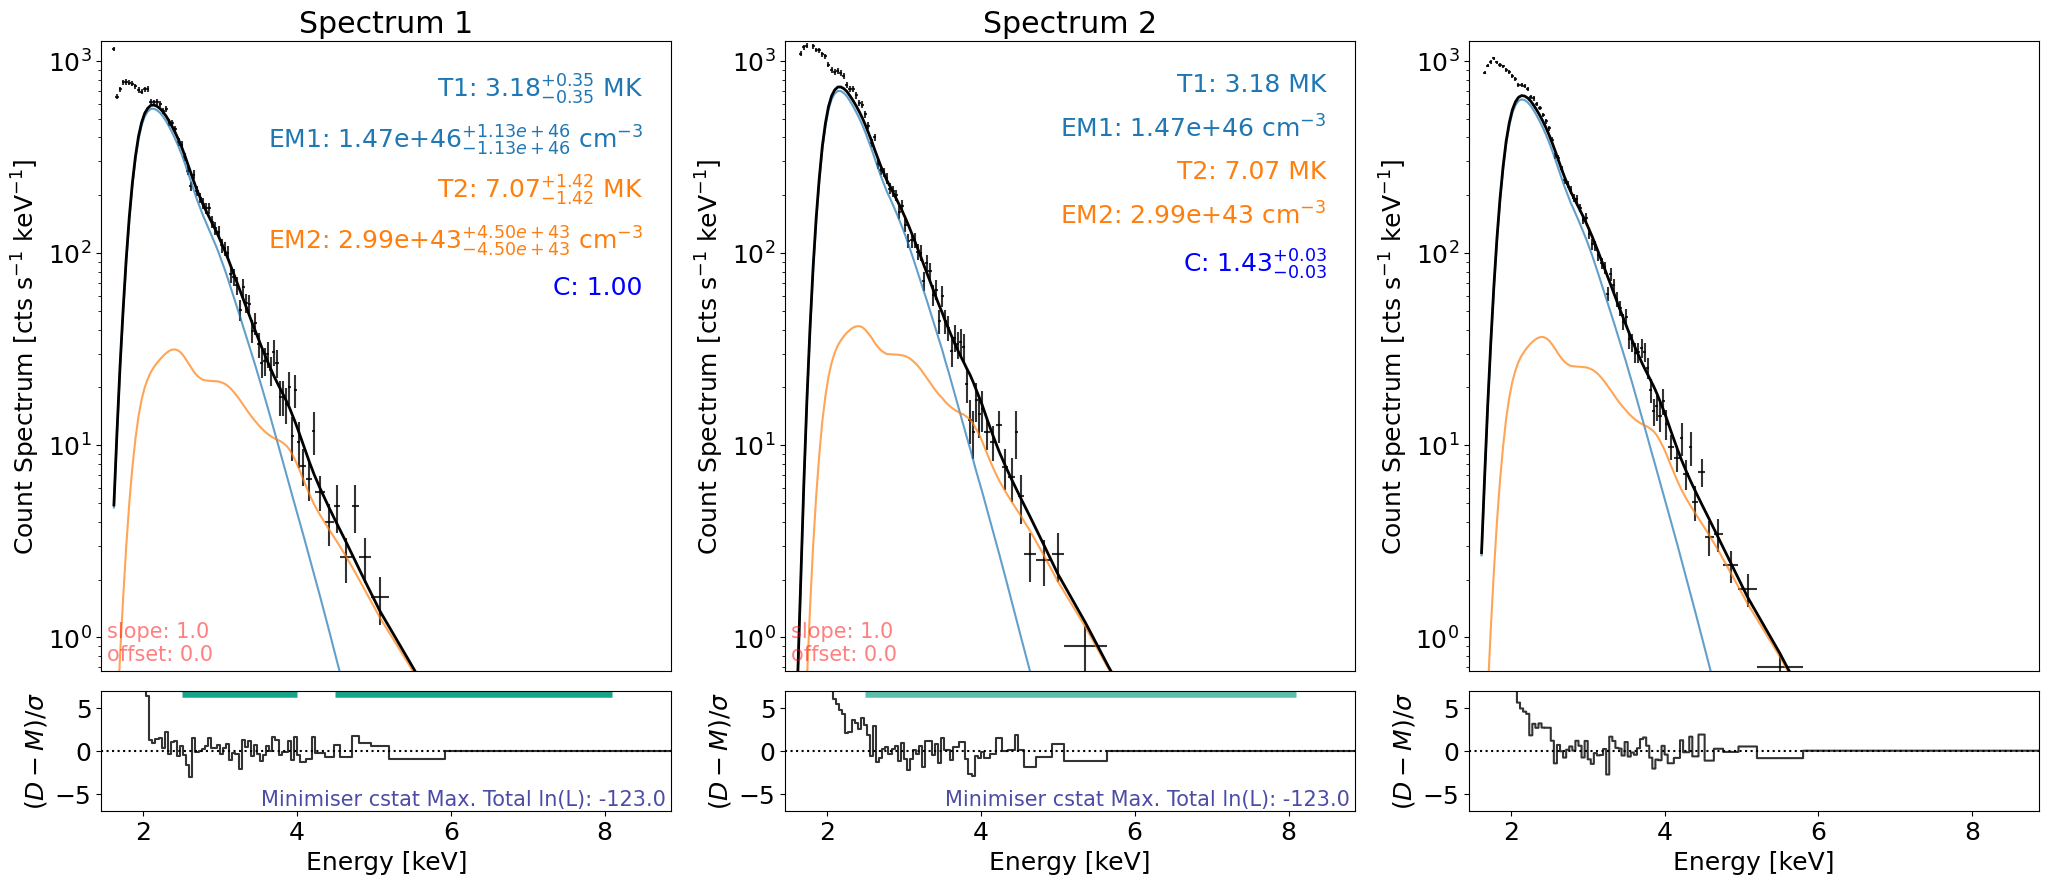

In [13]:
minimised_params = spec.fit()
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
try:
    axes, res_axes = spec.plot(rebin=12)
    for a in axes:
        a.set_xlim(x_limits)
        a.set_ylim(y_limits)
    plt.show()
    plt.rcParams["font.size"] = default_font_size
except ValueError as e:
    print(e)

**Add user defined sub-model**

Need to add function to the correct namespace for the fitter to see it and include the function name and parameters in `defined_photon_models` dictionary. This is done using the `add_photon_model()` function.

The `defined_photon_models` dictionary is what the sunkit-spex fitting uses to know what functions it can use to build with.

See what models are defined.

At the minute this is just the already defined module models `{'f_vth': ['T', 'EM'], 'thick_fn': ['total_eflux', 'index', 'e_c'], ...}`.



In [14]:
print("Defined models:\n", spec.defined_photon_models)

Defined models:
 {'f_vth': ['T', 'EM'], 'thick_fn': ['total_eflux', 'index', 'e_c'], 'thick_warm': ['tot_eflux', 'ind', 'ec', 'plasma_d', 'loop_temp', 'length']}


Define your sub-model in the same way you would define a total model (`f(*parameters,energies=None)`).

Model spectrum in units of photons s^-1 cm^-2 keV^-1 here (dimensions to make `model_spectrum#spectral_response` consistent with `count_spectrum`).

Parameter names cannot be any already defined in `defined_photon_models`.



In [15]:
def gauss(a, b, c, energies=None):
    # energies is given as energy bins, e.g., [[2.5,2.6], [2.6,2.7], [2.7,2.8], ...], so...
    mid_x = np.mean(energies, axis=1)
    return a * np.exp(-((mid_x - b) ** 2 / (2 * c**2)))

Essentially this is adding your model to the namespace that the fitting process uses to see what models are available to use:



In [16]:
spec.add_photon_model(gauss)

2026-07-16T23:05:14Z INFO sunkit_spex.legacy.fitting.fitter 801: Model gauss added.


Now defined_photon_models is `{'f_vth': ['T', 'EM'], 'thick_fn': ['total_eflux', 'index', 'e_c'], ..., 'gauss': ['a', 'b', 'c']}` and can use the gauss function:



In [17]:
print("Defined models, user's now included':\n", spec.defined_photon_models)

Defined models, user's now included':
 {'f_vth': ['T', 'EM'], 'thick_fn': ['total_eflux', 'index', 'e_c'], 'thick_warm': ['tot_eflux', 'ind', 'ec', 'plasma_d', 'loop_temp', 'length'], 'gauss': ['a', 'b', 'c']}


Now can use the user defined gauss model with already defined module models:

E.g. (use .update_model since the last one was `"C*(f_vth + f_vth)"` and still exists for spec object)



In [18]:
spec.update_model = "f_vth+gauss"

# spec.params.param_name -> [T1_spectrum1,EM1_spectrum1,a1_spectrum1,b1_spectrum1,c1_spectrum1]
print("Parameters\n", spec.params)

Parameters
                           Status  Value       Bounds       Error
T1_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
EM1_spectrum1               free    1.0  (0.0, None)  (0.0, 0.0)
a1_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
b1_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
c1_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
T1_spectrum2    tie_T1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
EM1_spectrum2  tie_EM1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
a1_spectrum2    tie_a1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
b1_spectrum2    tie_b1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
c1_spectrum2    tie_c1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)


**Can now use gauss photon model in the fitting**

Either by itself or in a greater, overall model defined as a named function, lambda function, or string.

Sort parameters:



In [19]:
spec.params["T1_spectrum1"] = {"Value": 3.05, "Bounds": (2.5, 6)}
spec.params["EM1_spectrum1"] = {"Value": 1.7, "Bounds": (0.5, 3.5)}

Then fit and plot again...



setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


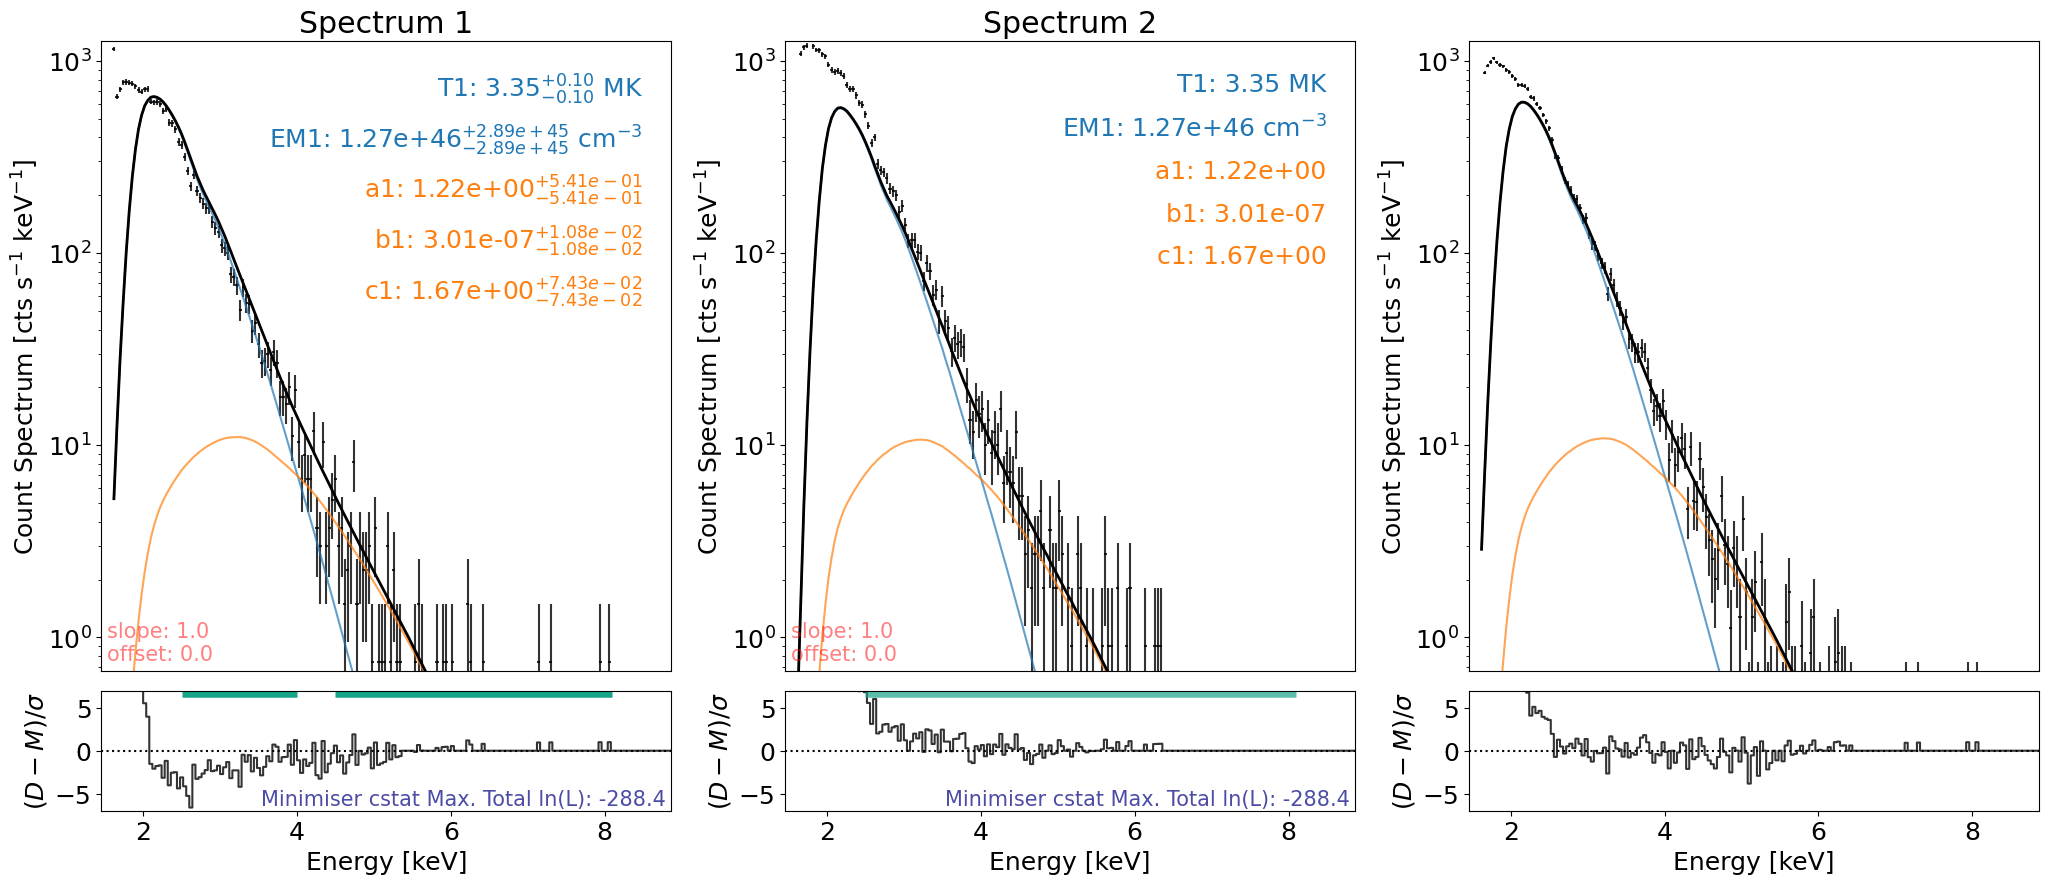

In [20]:
minimised_params = spec.fit()

plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
try:
    axes, res_axes = spec.plot()
    for a in axes:
        a.set_xlim(x_limits)
        a.set_ylim(y_limits)
    plt.show()
    plt.rcParams["font.size"] = default_font_size
except ValueError as e:
    print(e)

If the user's model function requires complicated variables/constants/etc., say large array loaded from a file, then this will not be seen if the session is save and loaded back in another time. To avoid this see the `add_var` function which works in a similar way to `add_photon_model` but for variables to be seen when pickling.

In addition to `add_photon_model` and `add_var` also having an `overwrite` input they also come with methods to remove any user added models or variables, such as `del_photon_model` and `del_var` which take the model/variable name as a string, respectively.


